In [ ]:
import pandas as pd
import numpy as np

df=pd.read_csv("../Datasets/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [74]:
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import train_test_split

df['Outcome'].value_counts() 

df_no_0 = df[(df['Glucose'] != 0) & (df['BloodPressure'] != 0) & (df['SkinThickness'] != 0) & (df['Insulin'] != 0) & (df['BMI'] != 0)]

X = df_no_0.drop(columns=['Outcome']) 
y = df_no_0['Outcome'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1) 

clf = tree.DecisionTreeClassifier(max_depth=2)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

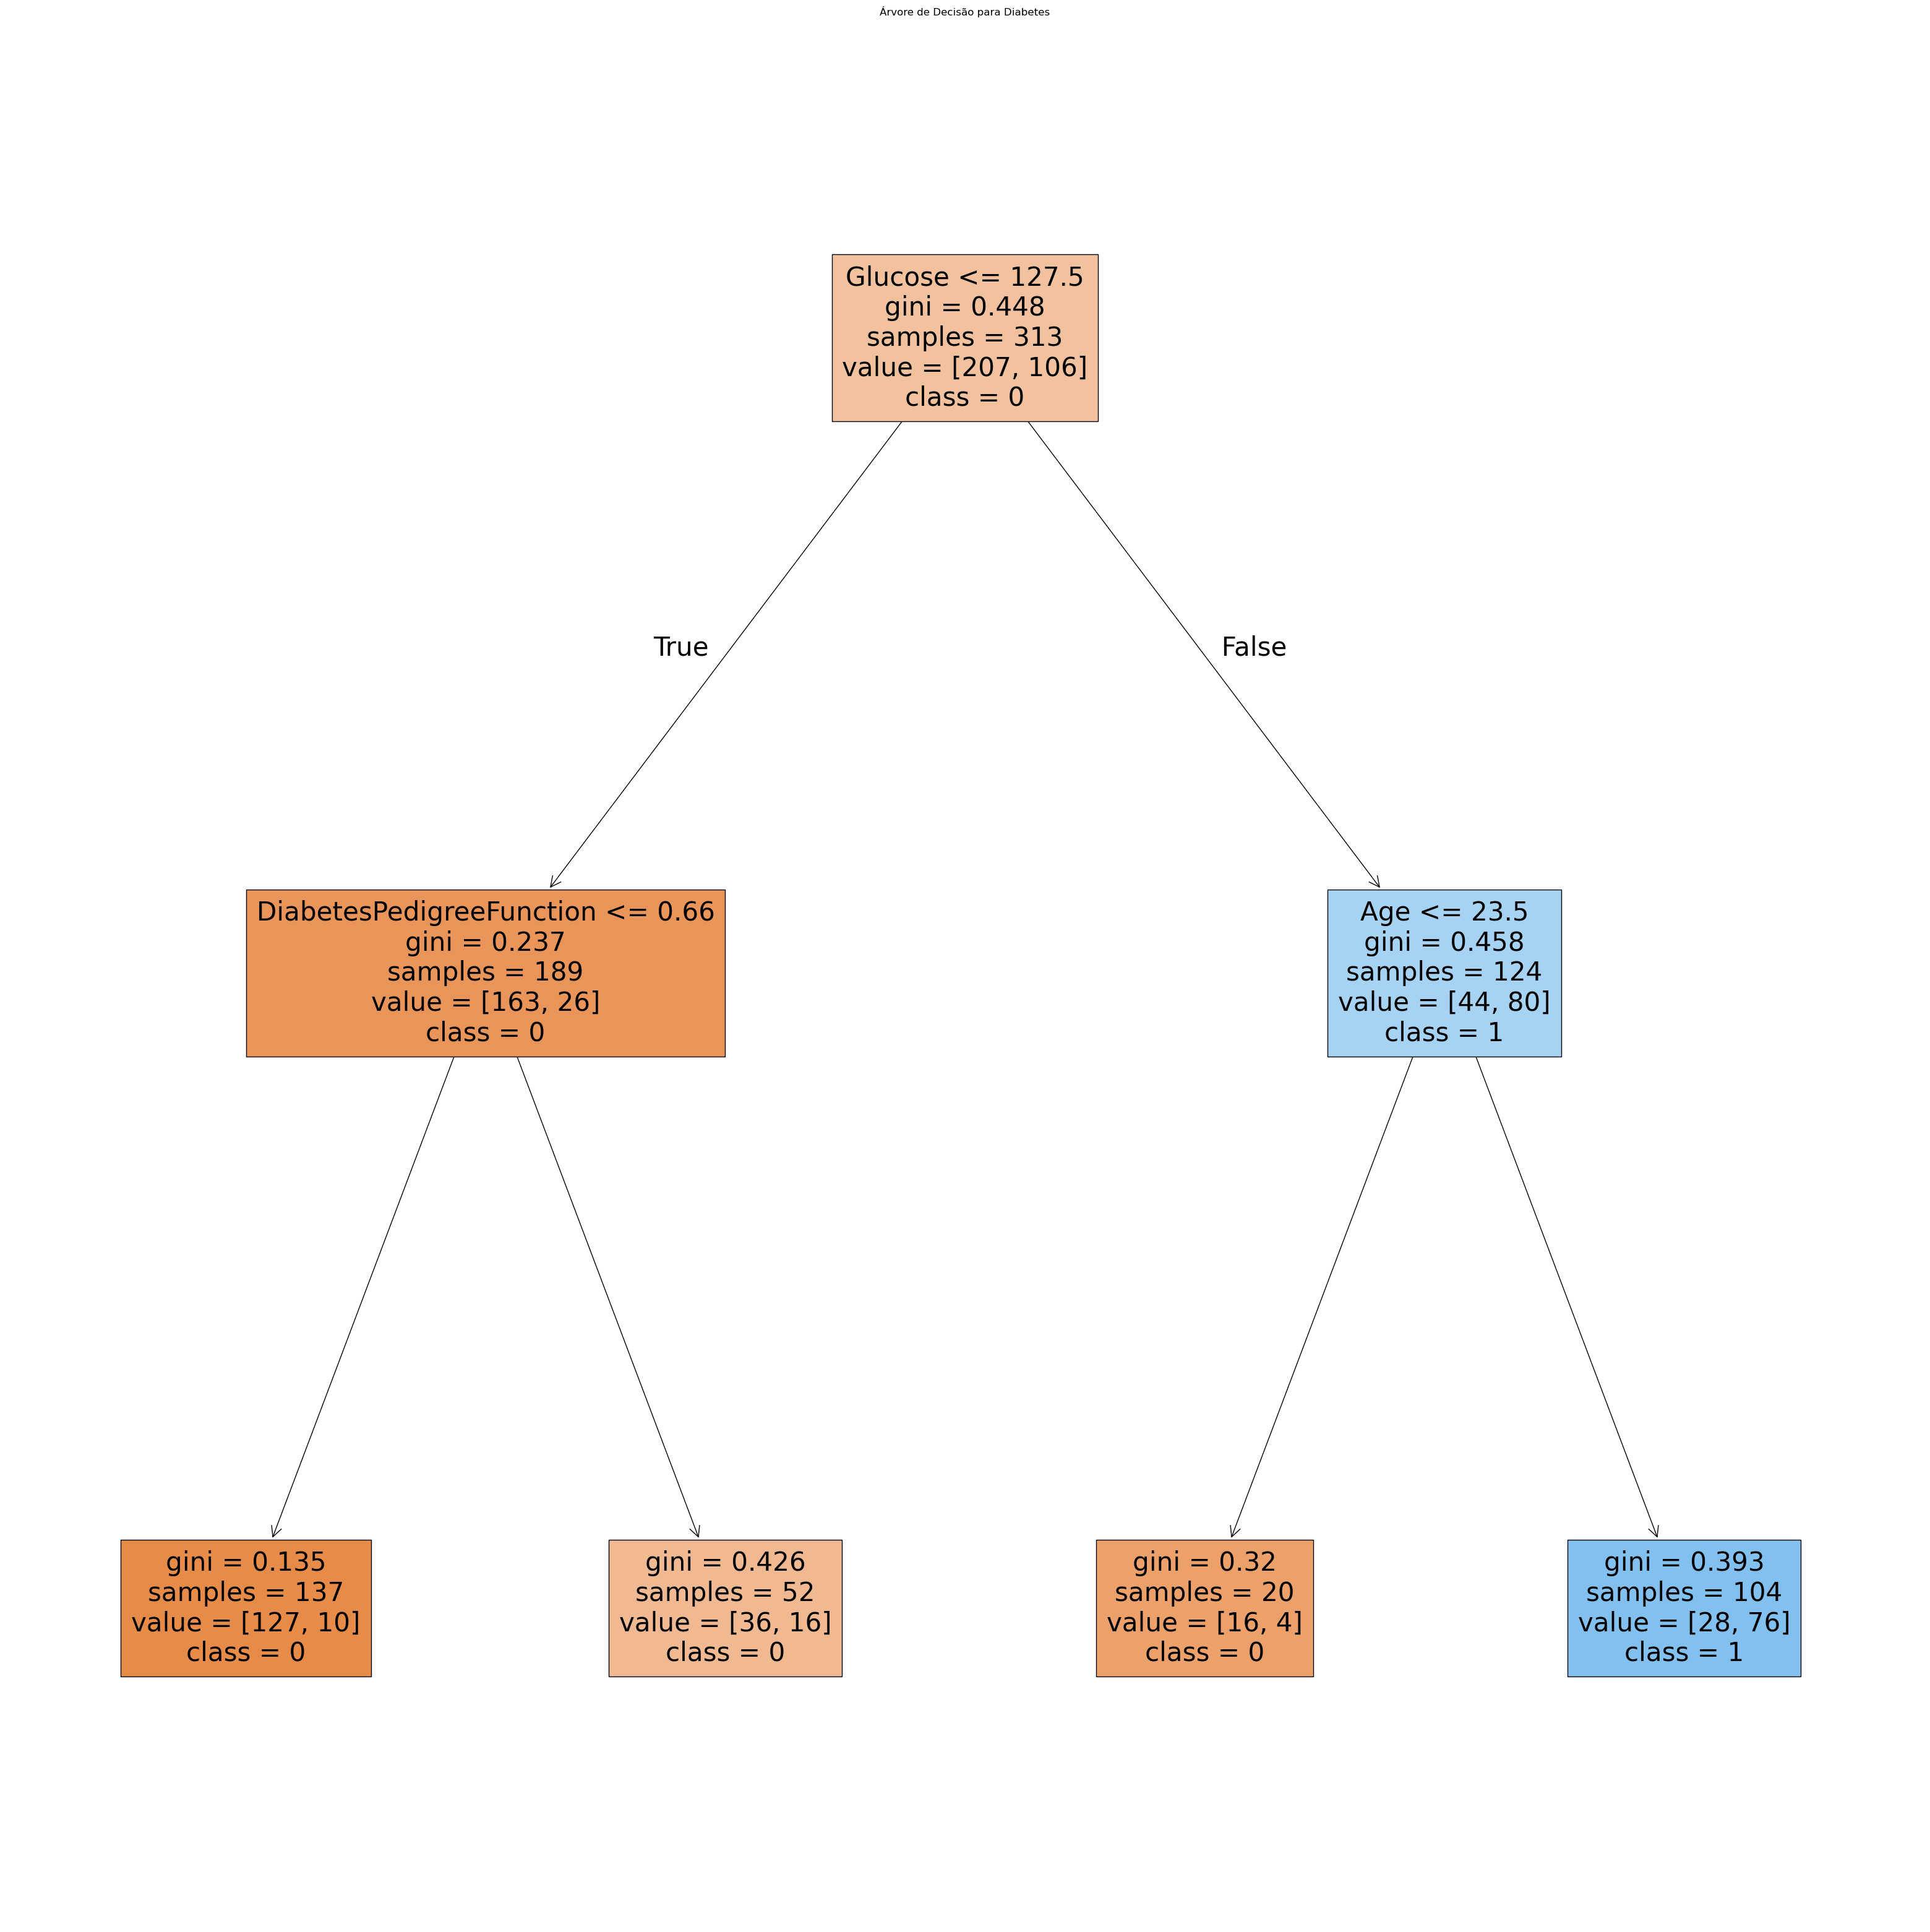

Precisão do modelo: 0.71


In [75]:
from sklearn.tree import plot_tree

plt.figure(figsize=(40,40))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=['0', '1']) 
plt.title("Árvore de Decisão para Diabetes")
plt.show()

accuracy= np.mean(y_pred == y_test)
print(f"Precisão do modelo: {accuracy:.2f}")

In [76]:
df_no_0.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1


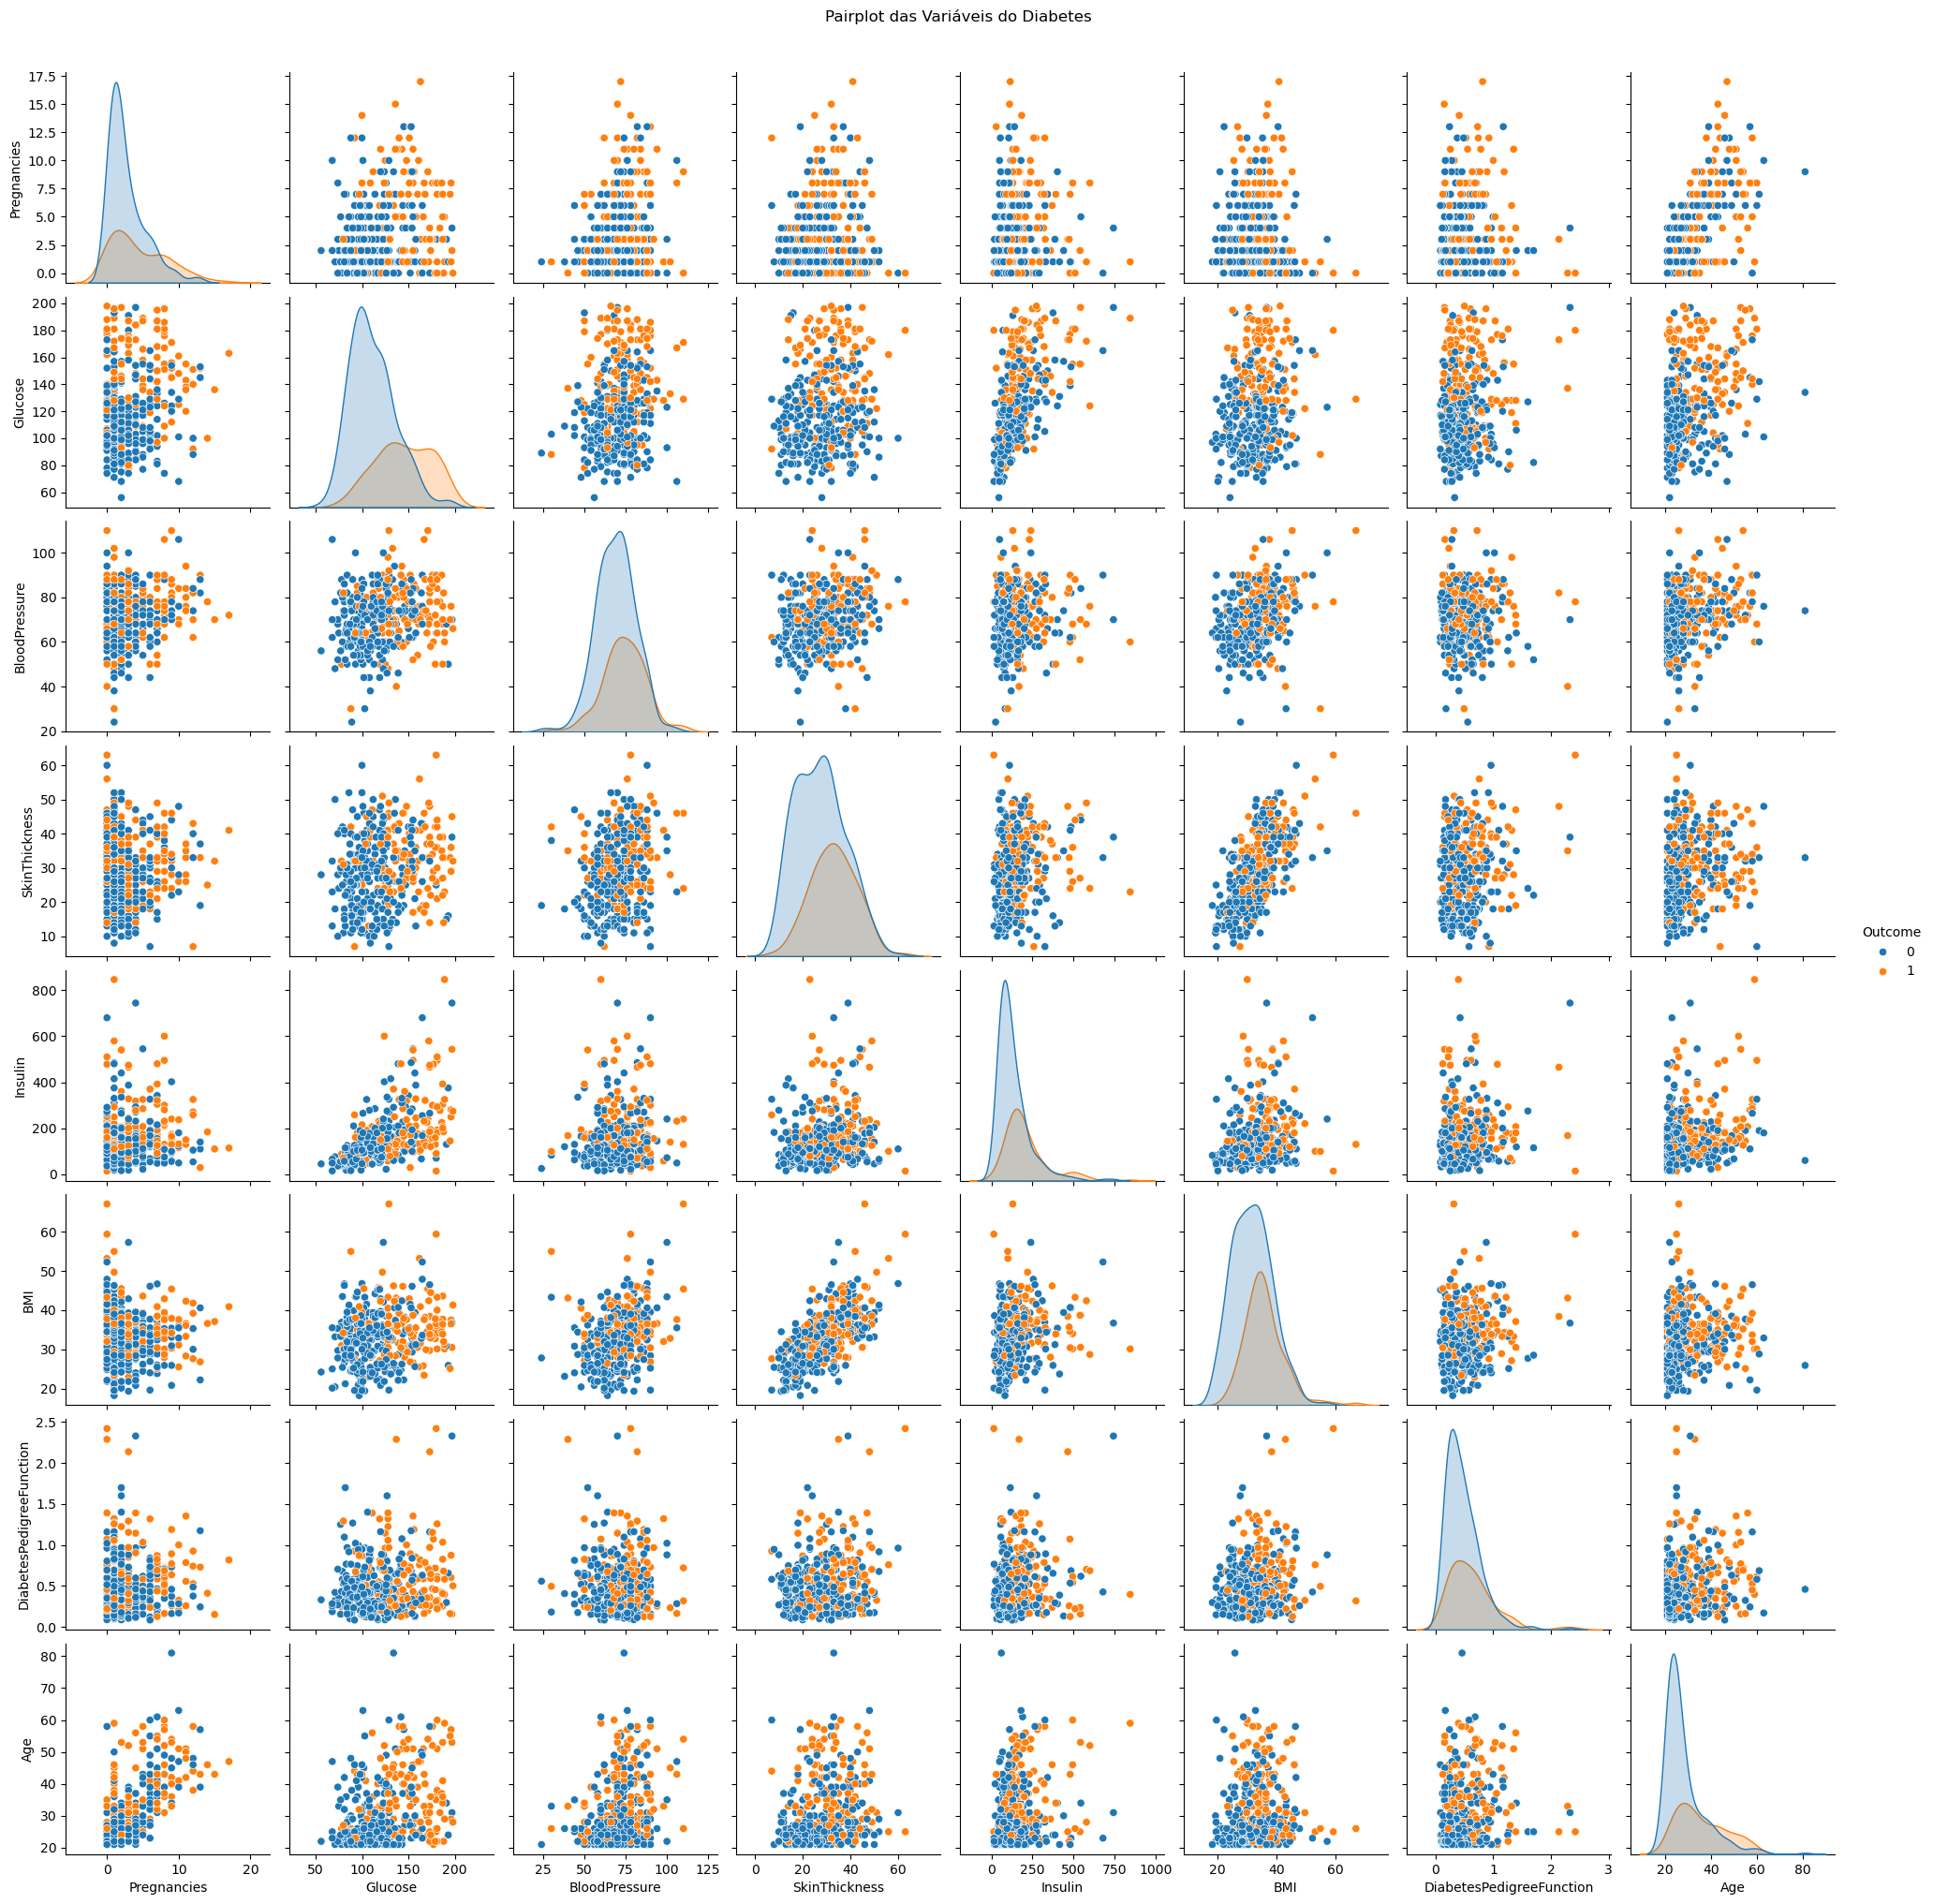

In [77]:
import seaborn as sns
pairplot = sns.pairplot(df_no_0, hue='Outcome')
pairplot.fig.suptitle("Pairplot das Variáveis do Diabetes", y=1.02)
plt.show()

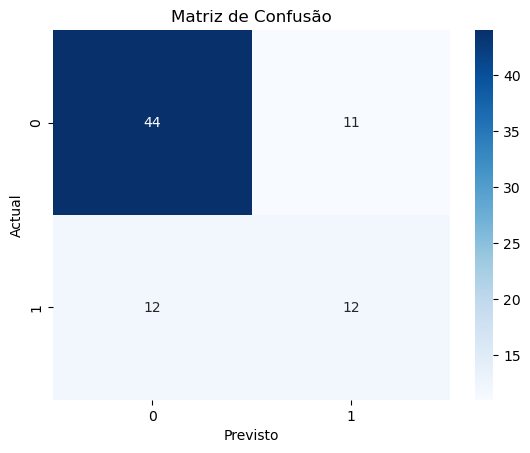

In [78]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Actual')
plt.title('Matriz de Confusão')
plt.show()
